In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import os

In [ ]:
Expr = pd.read_csv("mESC_RPKM.txt", sep='\t').drop("Entrez_ID", axis=1).set_index("Gene")
Expr.columns = ["BulkSeq-ESC_RPKM", "BulkSeq-EB_RPKM"]
Expr = np.log2(Expr + 1)
print(Expr.shape)

Expr.head()

(18936, 2)


,BulkSeq-ESC_RPKM,BulkSeq-EB_RPKM
Gene,,
Pzp,0.589626,0.008220
Aanat,0.456881,0.189396
Aatk,0.105295,0.093367
Abca1,1.565458,0.071959
Abca4,0.058168,0.148701


In [ ]:
dge1 = pd.read_csv("GSE75790_ziegenhain_complete_data.txt", sep='\t', index_col=0)
genename = pd.read_csv("genename2id.csv", index_col=0)

dge1 = dge1.loc[genename.ENSEMBL]
dge1.index = genename.SYMBOL
print(dge1.shape)

dge1.iloc[:5,:5]

(25695, 583)


,CELseq2A_ACGTAC,CELseq2A_ACGTGA,CELseq2A_ACGTTG,CELseq2A_ACTCTG,CELseq2A_AGACTC
SYMBOL,,,,,
Gnai3,4,1,1,4,1
Klf6,3,3,2,1,5
Scmh1,6,0,1,2,1
Cox5a,50,18,23,16,17
Ngfr,8,1,4,7,3


In [ ]:
%%time

dge2 = pd.read_csv("Microwell_mEs_dge.txt.gz", sep='\t', index_col=0)
dge2 = dge2.iloc[:, np.argsort(np.sum(dge2.values, 0))[::-1][:100]]
dge2.columns = dge2.columns.map(lambda x: "MicrowellSeq_"+x)

print(dge2.shape)

dge2.iloc[:5,:4]

(20198, 100)
CPU times: user 35 s, sys: 1.94 s, total: 36.9 s
Wall time: 36.9 s


,MicrowellSeq_CTCGCAGAACGCCAAAGT,MicrowellSeq_AACCTAGAACGCTTAACT,MicrowellSeq_ACACCCTAAGGGAAGTAC,MicrowellSeq_TGATCAAAGCGGGTCGGT
GENE,,,,
00R_AC107638.2,0,0,0,0
0610005C13Rik,0,0,0,0
0610007P14Rik,2,3,3,0
0610009B22Rik,3,4,1,1
0610009E02Rik,0,0,0,0


In [ ]:
dge3 = pd.read_csv("count10X.tsv", sep='\t', index_col=0)
print(dge3.shape)


(27998, 1956)


In [6]:
# 随机选择100个细胞的列索引
random_indices = np.random.choice(dge3.columns, size=100, replace=False)
dge3 = dge3[random_indices]
print(dge3.shape)  # 输出: (27998, 100)

dge3.iloc[:2,:3]

(27998, 100)


,10X_CTCGTCATCCCTCTTT-1,10X_TCTTCGGGTAGCGCTC-1,10X_TAGCCGGGTGAAAGAG-1
Xkr4,0,0,0
Gm1992,0,0,0


In [7]:
#基因取得是并集
dge = dge1.merge(dge2, left_index=True, right_index=True, how="outer").fillna(0)
print(dge.shape)

(30413, 683)


In [8]:
dge = dge.merge(dge3, left_index=True, right_index=True, how="outer").fillna(0)
print(dge.shape)

dge[:5]

(36063, 783)


,CELseq2A_ACGTAC,CELseq2A_ACGTGA,CELseq2A_ACGTTG,CELseq2A_ACTCTG,CELseq2A_AGACTC,CELseq2A_AGCTTC,CELseq2A_AGGATC,CELseq2A_AGTGCA,CELseq2A_AGTGTC,CELseq2A_CACTAG,...,10X_CGGACACAGCCCTAAT-1,10X_CAGCATACAAACTGCT-1,10X_GCTGCTTTCTGTTGAG-1,10X_TCGAGGCCATCGGTTA-1,10X_CGCTTCACAAAGTGCG-1,10X_TGACTTTGTCTTTCAT-1,10X_ACTATCTGTGCAGACA-1,10X_GCGGGTTCACTTGGAT-1,10X_TCGTACCAGTTTCCTT-1,10X_CACAGTATCCTTGGTC-1
SYMBOL,,,,,,,,,,,,,,,,,,,,,
00R_AC107638.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0610005C13Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0610007P14Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,4.0,2.0,0.0,5.0,0.0,2.0,1.0
0610009B22Rik,4.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,2.0,...,1.0,5.0,0.0,5.0,1.0,0.0,2.0,3.0,3.0,9.0
0610009E02Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
adata = sc.AnnData(dge.T)
adata.var_names_make_unique()
adata

/home/ggj/miniconda3/envs/nvwa2/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 783 × 36063

In [10]:
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.filter_genes(adata, min_cells = 1)
# sc.pp.filter_cells(adata, min_genes = 50)

sc.pp.log1p(adata, base = 2)
print(adata)

AnnData object with n_obs × n_vars = 783 × 22433
    var: 'n_cells'
    uns: 'log1p'


In [ ]:
adata.write("adata_mESCs.h5ad")

In [20]:
df = adata.to_df().T
# df.to_pickle("scTech_datasets/adata.p")

In [21]:
df = Expr.merge(df, left_index=True, right_index=True, how='outer').fillna(0)
print(df.shape)

df.iloc[:5,:4]

(28668, 785)


,BulkSeq-ESC_RPKM,BulkSeq-EB_RPKM,CELseq2A_ACGTAC,CELseq2A_ACGTGA
0610005C13Rik,0.000000,0.000000,0.0,0.0
0610006I08Rik,2.814521,3.666432,0.0,0.0
0610007C21Rik,3.959823,5.362259,0.0,0.0
0610007L01Rik,4.526391,4.902487,0.0,0.0
0610007P08Rik,4.988451,4.779710,0.0,0.0


<Axes: xlabel='BulkSeq-ESC_RPKM', ylabel='SmartSeqA_A10'>

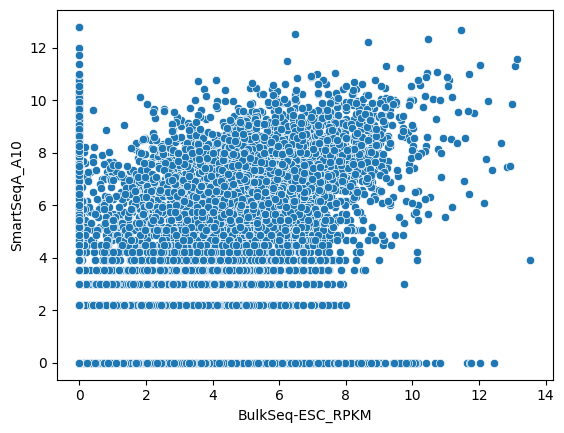

In [24]:
import seaborn as sns
sns.scatterplot(data=df, x="BulkSeq-ESC_RPKM", y="SmartSeqA_A10")

In [ ]:
df.to_pickle("adata_wgx.p")

In [ ]:
import pickle

adata_wgx = pd.read_pickle("adata_wgx.p")
adata_wgx.shape

(28668, 785)

In [11]:
print(adata_wgx.values.max())
print(adata_wgx.values.min())

18.31747311565643
0.0


In [ ]:
adata_wgx[:3]

In [12]:
stats = adata_wgx.describe().T  # 转置后按样本查看
stats['zeros_ratio'] = (adata_wgx == 0).mean()  # 每列零值比例
print(stats[['count', 'mean', 'min', 'max', 'zeros_ratio']])

                          count      mean  min        max  zeros_ratio
BulkSeq-ESC_RPKM        28668.0  1.539167  0.0  13.539086     0.422422
BulkSeq-EB_RPKM         28668.0  1.671909  0.0  14.141983     0.437073
CELseq2A_ACGTAC         28668.0  1.540248  0.0  14.921171     0.746721
CELseq2A_ACGTGA         28668.0  1.343167  0.0  15.384553     0.788161
CELseq2A_ACGTTG         28668.0  1.361145  0.0  15.250600     0.784847
...                         ...       ...  ...        ...          ...
10X_CGTTGGGGTCAACTGT-1  28668.0  1.205149  0.0  13.451810     0.806614
10X_GATCAGTAGGCACATG-1  28668.0  1.192927  0.0  13.062152     0.808183
10X_GTCGTAAAGGCATGTG-1  28668.0  1.002184  0.0  13.889191     0.852274
10X_TAGTGGTCAGTCGATT-1  28668.0  1.104788  0.0  13.377883     0.823985
10X_AAGGTTCCATTTCAGG-1  28668.0  1.141546  0.0  13.067219     0.821962

[785 rows x 5 columns]


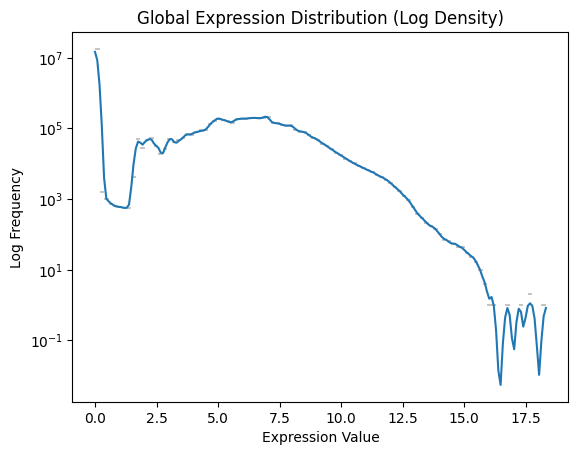

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 抽取所有值并绘制分布
all_values = adata_wgx.values.flatten()
sns.histplot(all_values, kde=True, bins=100, log_scale=(False, True))  # Y轴对数化
plt.title('Global Expression Distribution (Log Density)')
plt.xlabel('Expression Value')
plt.ylabel('Log Frequency')
plt.show()

In [15]:
adata_wgx_binary = adata_wgx.copy()
adata_wgx_binary[adata_wgx_binary >= 0.001] = 1
adata_wgx_binary[adata_wgx_binary < 0.001] = 0

In [ ]:
adata_wgx_binary = adata_wgx.copy()
adata_wgx_binary[adata_wgx_binary >= 0.001] = 1
adata_wgx_binary[adata_wgx_binary < 0.001] = 0

In [16]:
adata_wgx_binary[:3]

,BulkSeq-ESC_RPKM,BulkSeq-EB_RPKM,CELseq2A_ACGTAC,CELseq2A_ACGTGA,CELseq2A_ACGTTG,CELseq2A_ACTCTG,CELseq2A_AGACTC,CELseq2A_AGCTTC,CELseq2A_AGGATC,CELseq2A_AGTGCA,...,10X_AAGCCGCTCCTTTCTC-1,10X_CCTTTCTGTCAACATC-1,10X_CGGTTAACATCGGACC-1,10X_GTATTCTTCGTTTGCC-1,10X_GGGACCTAGCTATGCT-1,10X_CGTTGGGGTCAACTGT-1,10X_GATCAGTAGGCACATG-1,10X_GTCGTAAAGGCATGTG-1,10X_TAGTGGTCAGTCGATT-1,10X_AAGGTTCCATTTCAGG-1
0610005C13Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0610006I08Rik,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0610007C21Rik,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
adata_wgx_binary.to_pickle("./03_Benchmark_scTech_mESC_ljq_AUROC_binary/adata_wgx_binary.p")

In [ ]:
import pandas as pd
a1 = pd.read_csv('./03_Benchmark_scTech_mESC_ljq_AUROC_binary/Mouse_sctechnologies.annotation_wgx.tsv', sep='\t', header=0, encoding="unicode_escape")
print(a1.shape)
a1[:3]

(785, 4)


,Cell,Species,Celltype,Cluster
0,BulkSeq-ESC_RPKM,Mouse,BulkSeq-ESC,BulkSeq
1,BulkSeq-EB_RPKM,Mouse,BulkSeq-EB,BulkSeq
2,CELseq2A_ACGTAC,Mouse,CELseq2A,CELseq


In [3]:
a1['Cluster'].value_counts()

Cluster
SmartSeq2       157
SmartSeq        130
10X             100
MicrowellSeq    100
SCRBseq          84
DropSeq          76
CELseq           71
MARSseq          65
BulkSeq           2
Name: count, dtype: int64

In [ ]:
a3 = pd.read_csv('./03_Benchmark_scTech_mESC_ljq_AUROC_binary/Mouse_sctechnologies.annotation_wgx.tsv', sep='\t', header=0, encoding="unicode_escape")
print(a3.shape)
a3[:3]

(785, 4)


,Cell,Species,Celltype,Cluster
0,BulkSeq-ESC_RPKM,Mouse,BulkSeq-ESC,BulkSeq
1,BulkSeq-EB_RPKM,Mouse,BulkSeq-EB,BulkSeq
2,CELseq2A_ACGTAC,Mouse,CELseq2A,CELseq


In [ ]:
df = pd.read_pickle("./03_Benchmark_scTech_mESC_ljq_AUROC_binary/adata_wgx_binary.p")
df.shape

(28668, 785)

In [12]:
print(df.values.max())
print(df.values.min())

1.0
0.0


In [13]:
counts03 = df.stack().value_counts()  # stack()将多列展平为单列
print(counts03)

0.0    17829414
1.0     4674966
Name: count, dtype: int64


In [25]:
annotation = pd.DataFrame({"Cell":df.columns.values, "Species":"Mouse"})
annotation.head()

,Cell,Species
0,BulkSeq-ESC_RPKM,Mouse
1,BulkSeq-EB_RPKM,Mouse
2,CELseq2A_ACGTAC,Mouse
3,CELseq2A_ACGTGA,Mouse
4,CELseq2A_ACGTTG,Mouse


In [26]:
annotation["Celltype"] = annotation.Cell.apply(lambda x:x.split('_')[0])
annotation.head()

,Cell,Species,Celltype
0,BulkSeq-ESC_RPKM,Mouse,BulkSeq-ESC
1,BulkSeq-EB_RPKM,Mouse,BulkSeq-EB
2,CELseq2A_ACGTAC,Mouse,CELseq2A
3,CELseq2A_ACGTGA,Mouse,CELseq2A
4,CELseq2A_ACGTTG,Mouse,CELseq2A


In [27]:
np.unique(annotation.Celltype, return_counts=True)

(array(['10X', 'BulkSeq-EB', 'BulkSeq-ESC', 'CELseq2A', 'CELseq2B',
        'DropSeqA', 'DropSeqB', 'MARSseqA', 'MARSseqB', 'MicrowellSeq',
        'SCRBseqA', 'SCRBseqB', 'SmartSeq2A', 'SmartSeq2B', 'SmartSeqA',
        'SmartSeqB'], dtype=object),
 array([100,   1,   1,  34,  37,  42,  34,  29,  36, 100,  39,  45,  80,
         77,  69,  61]))

In [28]:
d = {'BulkSeq-EB': 'BulkSeq', 'BulkSeq-ESC': 'BulkSeq', 'CELseq2A':'CELseq', 'CELseq2B':'CELseq', 'DropSeqA':'DropSeq', 'DropSeqB':'DropSeq', 
     'MARSseqA':'MARSseq','MARSseqB':'MARSseq', 'MicrowellSeq':'MicrowellSeq', 'SCRBseqA':'SCRBseq', 'SCRBseqB':'SCRBseq', 
     'SmartSeq2A':'SmartSeq2','SmartSeq2B':'SmartSeq2', 'SmartSeqA':'SmartSeq', 'SmartSeqB':'SmartSeq','10X':'10X'}

In [29]:
annotation["Cluster"] = annotation["Celltype"].apply(lambda x:d[x]) 
np.unique(annotation.Cluster, return_counts=True)

(array(['10X', 'BulkSeq', 'CELseq', 'DropSeq', 'MARSseq', 'MicrowellSeq',
        'SCRBseq', 'SmartSeq', 'SmartSeq2'], dtype=object),
 array([100,   2,  71,  76,  65, 100,  84, 130, 157]))

In [ ]:
annotation.to_csv("Mouse_sctechnologies.annotation_wgx.tsv", sep='\t', index=None)

In [32]:
!head /home/ggj/Galaxy/00_NvTK/DataLJQ/scTech_datasets/Mouse_sctechnologies.annotation.tsv

Cell	Species	Celltype	Cluster
BulkSeq-ESC_RPKM	Mouse	BulkSeq-ESC	BulkSeq
BulkSeq-EB_RPKM	Mouse	BulkSeq-EB	BulkSeq
CELseq2A_ACGTAC	Mouse	CELseq2A	CELseq
CELseq2A_ACGTGA	Mouse	CELseq2A	CELseq
CELseq2A_ACGTTG	Mouse	CELseq2A	CELseq
CELseq2A_ACTCTG	Mouse	CELseq2A	CELseq
CELseq2A_AGACTC	Mouse	CELseq2A	CELseq
CELseq2A_AGCTTC	Mouse	CELseq2A	CELseq
CELseq2A_AGGATC	Mouse	CELseq2A	CELseq


In [2]:
import numpy as np
import scanpy as sc
import pandas as pd
import os

In [ ]:
df =  pd.read_pickle("scTech_datasets/adata_wgx.p")
print(df.shape)
df.iloc[:3,:5]

(28668, 785)


,BulkSeq-ESC_RPKM,BulkSeq-EB_RPKM,CELseq2A_ACGTAC,CELseq2A_ACGTGA,CELseq2A_ACGTTG
0610005C13Rik,0.000000,0.000000,0.0,0.0,0.0
0610006I08Rik,2.814521,3.666432,0.0,0.0,0.0
0610007C21Rik,3.959823,5.362259,0.0,0.0,0.0


In [ ]:
annotation =  pd.read_csv('./03_Benchmark_scTech_mESC_ljq_AUROC_binary/Mouse_sctechnologies.annotation_wgx.tsv',sep='\t')
print(annotation.shape)
annotation.head()

(785, 4)


,Cell,Species,Celltype,Cluster
0,BulkSeq-ESC_RPKM,Mouse,BulkSeq-ESC,BulkSeq
1,BulkSeq-EB_RPKM,Mouse,BulkSeq-EB,BulkSeq
2,CELseq2A_ACGTAC,Mouse,CELseq2A,CELseq
3,CELseq2A_ACGTGA,Mouse,CELseq2A,CELseq
4,CELseq2A_ACGTTG,Mouse,CELseq2A,CELseq


In [4]:
gene_detected_PCC = np.where(df > 0, 1, 0).sum(0) #参数 0表示沿列方向（axis=0）求和，即统计每列中 1的数量
print(gene_detected_PCC.shape)
gene_detected[:5]

(785,)


NameError: name 'gene_detected' is not defined

In [5]:
gene_detected_AUROC = np.where(df >= 0.001, 1, 0).sum(0) 
print(gene_detected_AUROC.shape)

(785,)


In [6]:
annotation["gene_detected_PCC"] = gene_detected_PCC
annotation["gene_detected_AUROC"] = gene_detected_AUROC
annotation.head()

,Cell,Species,Celltype,Cluster,gene_detected_PCC,gene_detected_AUROC
0,BulkSeq-ESC_RPKM,Mouse,BulkSeq-ESC,BulkSeq,16558,16558
1,BulkSeq-EB_RPKM,Mouse,BulkSeq-EB,BulkSeq,16138,16137
2,CELseq2A_ACGTAC,Mouse,CELseq2A,CELseq,7261,7261
3,CELseq2A_ACGTGA,Mouse,CELseq2A,CELseq,6073,6073
4,CELseq2A_ACGTTG,Mouse,CELseq2A,CELseq,6168,6168


In [7]:
Detected_gene = annotation.groupby('Cluster')[['gene_detected_PCC','gene_detected_AUROC']].mean().round().reset_index()

In [8]:
Detected_gene

,Cluster,gene_detected_PCC,gene_detected_AUROC
0,10X,4467.0,4467.0
1,BulkSeq,16348.0,16348.0
2,CELseq,6881.0,6881.0
3,DropSeq,3963.0,3963.0
4,MARSseq,3836.0,3836.0
5,MicrowellSeq,3462.0,3462.0
6,SCRBseq,6755.0,6755.0
7,SmartSeq,7038.0,7038.0
8,SmartSeq2,8457.0,8457.0


In [ ]:
Detected_gene.to_csv("./d3_DetectedGene/mESCs_baseline.tsv",index=None)

In [ ]:
df_magic =  pd.read_pickle("adata_MAGIC_wgx2.p")
print(df_magic.shape)
df[:3]

(28668, 783)


,BulkSeq-ESC_RPKM,BulkSeq-EB_RPKM,CELseq2A_ACGTAC,CELseq2A_ACGTGA,CELseq2A_ACGTTG,CELseq2A_ACTCTG,CELseq2A_AGACTC,CELseq2A_AGCTTC,CELseq2A_AGGATC,CELseq2A_AGTGCA,...,10X_AAGCCGCTCCTTTCTC-1,10X_CCTTTCTGTCAACATC-1,10X_CGGTTAACATCGGACC-1,10X_GTATTCTTCGTTTGCC-1,10X_GGGACCTAGCTATGCT-1,10X_CGTTGGGGTCAACTGT-1,10X_GATCAGTAGGCACATG-1,10X_GTCGTAAAGGCATGTG-1,10X_TAGTGGTCAGTCGATT-1,10X_AAGGTTCCATTTCAGG-1
0610005C13Rik,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0610006I08Rik,2.814521,3.666432,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0610007C21Rik,3.959823,5.362259,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
print(df_magic.values.max())
print(np.median(df_magic.values)) 
print(df_magic.values.min())

15.041545111370567
0.036261887849114445
0.0


In [ ]:
annotation_magic =  pd.read_csv('Mouse_sctechnologies_MAGIC.annotation_wgx.tsv',sep='\t')
print(annotation_magic.shape)
annotation_magic.head()

(783, 4)


,Cell,Species,Celltype,Cluster
0,MAGIC-CELseq2A_ACGTAC,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq
1,MAGIC-CELseq2A_ACGTGA,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq
2,MAGIC-CELseq2A_ACGTTG,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq
3,MAGIC-CELseq2A_ACTCTG,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq
4,MAGIC-CELseq2A_AGACTC,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq


In [19]:
gene_detected_magic_PCC = np.where(df_magic > 0, 1, 0).sum(0) 
print(gene_detected_magic_PCC.shape)
gene_detected_magic_AUROC = np.where(df_magic >= 0.001, 1, 0).sum(0) 
print(gene_detected_magic_AUROC.shape)
gene_detected_magic_AUROC_median = np.where(df_magic >= 0.036, 1, 0).sum(0) 
print(gene_detected_magic_AUROC_median.shape)

(783,)
(783,)
(783,)


In [20]:
annotation_magic["gene_detected_PCC"] = gene_detected_magic_PCC
annotation_magic["gene_detected_AUROC"] = gene_detected_magic_AUROC_median
annotation_magic.head()

,Cell,Species,Celltype,Cluster,gene_detected_PCC,gene_detected_AUROC
0,MAGIC-CELseq2A_ACGTAC,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq,15258,14876
1,MAGIC-CELseq2A_ACGTGA,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq,15258,14989
2,MAGIC-CELseq2A_ACGTTG,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq,15258,14969
3,MAGIC-CELseq2A_ACTCTG,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq,15258,14797
4,MAGIC-CELseq2A_AGACTC,MAGIC-Mouse,MAGIC-CELseq2A,MAGIC-CELseq,15258,14861


In [14]:
Detected_gene_magic = annotation_magic.groupby('Cluster')[['gene_detected_PCC','gene_detected_AUROC']].mean().round().reset_index()

In [15]:
Detected_gene_magic

,Cluster,gene_detected_PCC,gene_detected_AUROC
0,MAGIC-10X,14642.0,14638.0
1,MAGIC-CELseq,15258.0,15258.0
2,MAGIC-DropSeq,13793.0,13793.0
3,MAGIC-MARSseq,13238.0,13238.0
4,MAGIC-MicrowellSeq,15010.0,15010.0
5,MAGIC-SCRBseq,14143.0,14143.0
6,MAGIC-SmartSeq,16808.0,16808.0
7,MAGIC-SmartSeq2,17441.0,17441.0


In [ ]:
Detected_gene_magic.to_csv("mESCs_magic.tsv",index=None)

In [ ]:
annotation_magic.to_csv("annotation_mESCs_magic.tsv",index=None)
annotation.to_csv("annotation_mESCs.tsv",index=None)

In [ ]:
annotation_magic.to_csv("annotation_mESCs_magic_median.tsv",index=None)

In [ ]:
import h5py


file_path = 'Dataset_mESCs_chr8_train_test_20250706_binary.h5'
h5file = h5py.File(file_path, 'r')

anno = h5file["annotation"][:]
x_train = h5file["train_data"][:].astype(np.float32)
y_train = h5file["train_label"][:].astype(np.float32)
x_val = h5file["val_data"][:].astype(np.float32)
y_val = h5file["val_label"][:].astype(np.float32)
x_test = h5file["test_data"][:].astype(np.float32)
y_test = h5file["test_label"][:].astype(np.float32)
test_gene = h5file["test_gene"][:]
h5file.close()

In [3]:
anno = pd.DataFrame(anno, columns=["Cell", "Species", "Celltype", "Cluster"])

In [2]:
#anno

In [ ]:
load_params = torch.load("./d2_MCL/MCA_scMTLoss_Celltype/Log/best_model.p")
print(load_params)

Net(
  (Embedding): CNN(
    (conv1): Sequential(
      (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,))
      (activate): ReLU()
      (pool): AvgPool1d(kernel_size=(15,), stride=(15,), padding=(0,))
    )
    (conv2): Sequential(
      (conv): Conv1d(128, 256, kernel_size=(7,), stride=(1,), dilation=(2,))
      (activate): ReLU()
      (pool): AvgPool1d(kernel_size=(7,), stride=(7,), padding=(0,))
    )
    (globalpooling): AdaptiveAvgPool1d(output_size=64)
  )
  (MLP): MLP(
    (fc1): Sequential(
      (0): Linear(in_features=16384, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (task_b'Mouse'): MLP(
    (fc1): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
    )
    (pred): Sequential(
      (0): Linear(in_features=256, out_features=179344, bias=True)
      (1): Sigmoid()
    )
  )
  (cat_task): ConcatenateTask()
)


In [ ]:
technologies = adata.obs['technology'].unique()
corrected_adatas = []

for tech in technologies:
    # 过滤当前技术平台的数据
    tech_mask = adata.obs['technology'] == tech
    adata_tech = adata[tech_mask].copy()
    
    # 检查是否有A/B批次（需至少两个批次）
    if len(adata_tech.obs['experiment'].unique()) >= 2:
        print(f"\nProcessing {tech} with batches: {adata_tech.obs['experiment'].unique()}")
        
        # 标准化和PCA降维（Harmony需要）
        sc.pp.normalize_total(adata_tech, target_sum=1e4)
        sc.pp.log1p(adata_tech)
        sc.pp.highly_variable_genes(adata_tech, n_top_genes=2000)
        sc.pp.pca(adata_tech, n_comps=50)
        
        # 使用Harmony去批次（基于experiment列）
        sc.external.pp.harmony_integrate(
            adata_tech, 
            key='experiment',  # 指定A/B批次列
            basis='X_pca',     # 基于PCA结果
            max_iter_harmony=20
        )
        
        # 保存校正后的数据
        corrected_adatas.append(adata_tech)
    else:
        print(f"Skipping {tech}: only 1 batch found.")

# 合并所有校正后的数据
adata_corrected = sc.concat(corrected_adatas, merge='same')

In [38]:
!head /home/ggj/Galaxy/01_benmark_data/01_run/BIB/01_Benchmark_scTech_mESC_ljq_PCC/Mouse_sctechnologies.annotation_wgx.tsv

Cell	Species	Celltype	Cluster
BulkSeq-ESC_RPKM	Mouse	BulkSeq-ESC	BulkSeq
BulkSeq-EB_RPKM	Mouse	BulkSeq-EB	BulkSeq
CELseq2A_ACGTAC	Mouse	CELseq2A	CELseq
CELseq2A_ACGTGA	Mouse	CELseq2A	CELseq
CELseq2A_ACGTTG	Mouse	CELseq2A	CELseq
CELseq2A_ACTCTG	Mouse	CELseq2A	CELseq
CELseq2A_AGACTC	Mouse	CELseq2A	CELseq
CELseq2A_AGCTTC	Mouse	CELseq2A	CELseq
CELseq2A_AGGATC	Mouse	CELseq2A	CELseq
